<h1 style="text-align: center; font-family: 'Roboto', sans-serif; font-weight:bold; font-size:40px; margin: 40px 0">05 - Modélisation & Comparaison de Modèles</h1>

### Objectif
Ce notebook couvre la **modélisation prédictive** de l'attrition RH à partir du dataset consolidé `merged_data.csv`.
L'objectif est de construire et **comparer plusieurs classifieurs** pour justifier le choix du meilleur modèle,
tout en respectant les contraintes de fuite de données, de déséquilibre de classe et d'interprétabilité.

### Plan de ce notebook
1. Importation des bibliothèques nécessaires
2. Préparation des Jeux de Données
3. Rappel - Métriques de Performance
4. Comparaison des Modèles
5. Analyse du Modèle Prédictif
6. Transparence

### Prérequis
- Avoir exécuté les notebooks [EDA - Données Statiques](./01_eda_static_data.ipynb), [EDA - Feature Engineering Temporel](./02_eda_temporal_and_outliers.ipynb), [EDA - Fusion des Données](./03_eda_merge_data.ipynb) et [EDA - Analyse des Données](./04_eda_analysis.ipynb) .
- Le fichier `src/data/processed/merged_data.csv` doit exister.

---
## **1. Importation des bibliothèques nécessaires**

In [ ]:
import warnings
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# -- Classifieurs retenus (cf. §5 pour la justification du choix) -----------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
)
from sklearn.svm import SVC

# -- Réseau de neurones (comparaison §7) ------------------------------------
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
os.environ['PYTHONWARNINGS'] = 'ignore'  # Propage aux workers joblib

# -- Chemins ----------------------------------------------------------------
DATA_FILE_PATH = '../data/processed/merged_data.csv'

# -- Configuration ML -------------------------------------------------------
RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_SPLITS     = 5
TARGET_COL   = 'has_left'

# -- Styles visuels (cohérence avec notebooks précédents) -------------------
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE     = {0: '#4A90D9', 1: '#E05C5C'}
SNS_PALETTE = ['#4A90D9', '#E05C5C']
LABELS      = {0: 'Resté (0)', 1: 'Parti (1)'}

print('Les bibliothèques ont été importées correctement !')

Les bibliothèques ont été importées correctement !


---
## **2. Préparation des Jeux de Données**

Dans cette section, il est question de préparer le jeu de données en jeux de données d'entraînement et de test pour pouvoir comparer les modèles.

Nous effectuerons ceci selon le plan suivant :
- Sélection des features
- Séparation test-train set
- Préprocessing & Pipeline

In [2]:
df = pd.read_csv(DATA_FILE_PATH)
print(f"Dimensions : {df.shape}")
print(f"\nRépartition de la cible '{TARGET_COL}' :")
print(df[TARGET_COL].value_counts())
print(f"\nTaux d'attrition : {df[TARGET_COL].mean():.1%}")
df.head()

Dimensions : (4410, 24)

Répartition de la cible 'has_left' :
has_left
0    3699
1     711
Name: count, dtype: int64

Taux d'attrition : 16.1%


,has_left,business_travel,department,education,education_field,job_level,job_role,monthly_income,percent_salary_hike,total_working_years,...,environment_satisfaction,job_satisfaction,work_life_balance,job_involvement,performance_rating,avg_hours_per_day,std_hours_daily,std_hours_monthly,total_days_worked,overtime_ratio
0,0,1,Sales,2,LifeSci,1,HealthRep,131160,11,1,...,3,4,2,3,3,7.373651,0.283224,0.051012,232,0.000000
1,1,2,R&D,1,LifeSci,1,Scientist,41890,23,6,...,3,2,4,2,4,7.718969,0.313351,0.080174,236,0.177966
2,0,2,R&D,4,Other,4,SalesExec,193280,15,5,...,2,2,1,3,3,7.013240,0.311551,0.069011,242,0.000000
3,0,0,R&D,5,LifeSci,3,HR,83210,11,13,...,4,4,3,2,3,7.193678,0.284133,0.069819,235,0.000000
4,0,1,R&D,1,Medical,1,SalesExec,23420,12,9,...,4,1,3,3,3,8.006175,0.300656,0.048139,245,0.469388


### 2.1. Sélection et préparation des feature

Avant de séparer les données, il faut décider quelles features conserver.
Le notebook 04 a mis en évidence une forte corrélation (`0.91`) entre `avg_hours_per_day` et `overtime_ratio`.
Conserver les deux features fortement corrélées peut fausser l'importance relative des variables dans certains modèles.

In [3]:
COLS_TO_DROP = [
    'overtime_ratio', 'percent_salary_hike', 'years_with_curr_manager'
]

# On sépare les features de la cible
X = df.drop(columns=[TARGET_COL] + COLS_TO_DROP)
y = df[TARGET_COL]

# On récupère les listes de features numériques et catégorielles
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(exclude='number').columns.tolist()

print(f"Features numériques ({len(numeric_features)}) :")
print(f"  {numeric_features}")
print(f"\nFeatures catégorielles ({len(categorical_features)}) :")
print(f"  {categorical_features}")
print(f"\nX : {X.shape} | y : {y.shape}")
print(f"\nFeatures supprimées : {COLS_TO_DROP}")

Features numériques (17) :
  ['business_travel', 'education', 'job_level', 'monthly_income', 'total_working_years', 'training_times_last_year', 'years_at_company', 'years_since_last_promotion', 'environment_satisfaction', 'job_satisfaction', 'work_life_balance', 'job_involvement', 'performance_rating', 'avg_hours_per_day', 'std_hours_daily', 'std_hours_monthly', 'total_days_worked']

Features catégorielles (3) :
  ['department', 'education_field', 'job_role']

X : (4410, 20) | y : (4410,)

Features supprimées : ['overtime_ratio', 'percent_salary_hike', 'years_with_curr_manager']


### 2.2. Séparation train-test set

In [4]:
# On split les données en train/test avec stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

# On vérifie la répartition de la cible dans les sets train/test
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"\nProportions '{TARGET_COL}' :")
print(f"  Total  : {y.mean():.1%}")
print(f"  Train  : {y_train.mean():.1%}")
print(f"  Test   : {y_test.mean():.1%}")

Train : 3528 lignes | Test : 882 lignes

Proportions 'has_left' :
  Total  : 16.1%
  Train  : 16.1%
  Test   : 16.1%


### 2.3. Preprocessing & Pipeline

Une pipeline chaîne les transformations et le classifieur en un seul objet.
Cela garantit que le `StandardScaler` est **fitté uniquement sur le train set** à chaque fold de cross-validation,
et appliqué (sans re-fit) sur le fold de validation et le test set final.

In [5]:
# -- Préprocesseur ---------------------------------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop',
)

MODELS_CONFIG = {
    'LogisticRegression': {
        'classifier': LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
        ),
        'params': {
            'classifier__C'      : [0.01, 0.1, 1.0, 10.0],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver' : ['liblinear'],   # seul solver supportant L1
        },
    },

    'RandomForest': {
        'classifier': RandomForestClassifier(
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
        ),
        'params': {
            'classifier__n_estimators'  : [100, 200, 300],
            'classifier__max_depth'     : [None, 10, 20],
            'classifier__min_samples_leaf': [1, 5, 10],
            'classifier__max_features'  : ['sqrt', 'log2'],
        },
    },

    'ExtraTrees': {
        # Comme RandomForest mais splits totalement aléatoires -> plus rapide,
        # variance plus faible, souvent meilleur recall sur cible déséquilibrée
        'classifier': ExtraTreesClassifier(
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
        ),
        'params': {
            'classifier__n_estimators'    : [100, 200, 300],
            'classifier__max_depth'       : [None, 10, 20],
            'classifier__min_samples_leaf': [1, 5, 10],
        },
    },

    'GradientBoosting': {
        # Pas de class_weight natif -> la grille explore subsample pour
        # compenser partiellement ; le déséquilibre sera géré par le seuil
        'classifier': GradientBoostingClassifier(random_state=RANDOM_STATE),
        'params': {
            'classifier__n_estimators' : [100, 200],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__max_depth'    : [3, 5, 7],
            'classifier__subsample'    : [0.8, 1.0],
        },
    },

    'SVC': {
        # probability=True indispensable pour predict_proba -> ROC-AUC
        'classifier': SVC(
            kernel='rbf', class_weight='balanced',
            probability=True, random_state=RANDOM_STATE
        ),
        'params': {
            'classifier__C'    : [0.1, 1.0, 10.0, 100.0],
            'classifier__gamma': ['scale', 'auto'],
        },
    },
}

print(f"{len(MODELS_CONFIG)} modèles configurés :")
for name in MODELS_CONFIG:
    print(f"  - {name}")

5 modèles configurés :
  - LogisticRegression
  - RandomForest
  - ExtraTrees
  - GradientBoosting
  - SVC


---
## **3. Rappel - Métriques de Performance**

Avant de lancer la comparaison, voici les métriques utilisées pour interpréter les résultats.
Comprendre leur signification est indispensable pour choisir **le bon critère de sélection du modèle**
selon l'objectif métier.

Nous effectuerons ceci selon le plan suivant :
- Précision Globale
- Précision
- Rappel
- F1-Score
- Matrice de Confusion
- Courbe ROC et AUC

### 3.1. Précision globale (Accuracy)

$$\text{Accuracy} = \frac{VP + VN}{VP + VN + FP + FN}$$

**À éviter sur ce dataset.** En effet, avec ~85% de classe négative, un modèle qui prédit
systématiquement "Resté" atteint 85% d'accuracy sans jamais détecter un départ.

### 3.2. Précision (Precision)

$$\text{Precision} = \frac{VP}{VP + FP}$$

Parmi tous les employés **prédits comme partants**, quelle proportion l'est réellement ?
- Précision faible -> beaucoup de faux positifs (alertes inutiles, coût RH élevé).

### 3.3. Rappel (Recall)

$$\text{Recall} = \frac{VP}{VP + FN}$$

Parmi tous les employés **qui partent réellement**, quelle proportion est détectée ?
- **Métrique prioritaire ici** : un départ non détecté (FN) est plus coûteux qu'une fausse alerte.

### 3.4. F1-Score

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Moyenne harmonique entre Précision et Recall. Utile pour **équilibrer les deux** quand aucun
des deux ne doit être sacrifié. **Métrique de sélection finale du meilleur modèle** dans ce notebook.

### 3.5. Matrice de Confusion

$$\begin{array}{|c|c|c|}
\hline
 & \textbf{Prédit Positif (Parti)} & \textbf{Prédit Négatif (Resté)} \\
\hline
\textbf{Réel Positif (Parti)} & VP \text{ (vrais positifs)} & FN \text{ (faux négatifs)} \\
\hline
\textbf{Réel Négatif (Resté)} & FP \text{ (faux positifs)} & VN \text{ (vrais négatifs)} \\
\hline
\end{array}$$

- **FN** = départs réels non détectés -> coût métier élevé (perte de talent sans anticipation)
- **FP** = alertes inutiles -> coût faible (entretien préventif inutile)

### 3.6. Courbe ROC et AUC

La courbe ROC trace le **Taux de Vrais Positifs (TPR)** contre le **Taux de Faux Positifs (FPR)**
pour tous les seuils de décision possibles.

$$TPR = \frac{VP}{VP + FN} \qquad FPR = \frac{FP}{FP + VN}$$

L'**AUC** (aire sous la courbe ROC) mesure la capacité de **discrimination globale** du modèle,
indépendamment du seuil choisi - utile pour comparer des modèles sur données déséquilibrées.

| AUC | Interprétation |
|---|---|
| 0.9 – 1.0 | Excellente discrimination |
| 0.8 – 0.9 | Bonne discrimination |
| 0.7 – 0.8 | Acceptable |
| 0.6 – 0.7 | Faible |
| 0.5 – 0.6 | Pas mieux que l'aléatoire |


**Dans ce notebook**, le ROC-AUC est utilisé comme **critère d'optimisation CV** (indépendant du seuil),
et le **F1-Score** comme **critère de sélection finale** du meilleur modèle sur le test set.

---
## **4. Comparaison multi-modèles**

Plutôt que de choisir un classifieur arbitrairement, nous entraînons **plusieurs modèles** dans les mêmes
conditions (même split, même `StratifiedKFold`, même métrique) pour comparer leurs performances de façon équitable.

Nous effecturons cette comparaison selon le plan suivant :
- Stratégie d'optimisation
- Tableau Comparatif
- Diagnostic
- Comparaison avec un Réseau de Neurones

### 4.1. Stratégie d'optimisation

Pour chaque modèle, `GridSearchCV` explore la grille d'hyperparamètres et sélectionne **automatiquement**
la combinaison optimale selon le ROC-AUC en validation croisée stratifiée.

Le ROC-AUC est choisi comme métrique CV car il est **indépendant du seuil de décision** et
mesure la capacité de discrimination globale, ce qui est particulièrement utile sur une cible déséquilibrée.

In [6]:
import warnings
import time

# -- Validation croisée stratifiée -----------------------------------------
cv      = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = 'roc_auc'

# -- Boucle d'entraînement -------------------------------------------------
results_models = {}

for model_name, config in MODELS_CONFIG.items():
    print(f"\n{'-'*60}")
    print(f"  {model_name}")
    print(f"{'-'*60}")

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   config['classifier']),
    ])

    search = GridSearchCV(
        pipe,
        config['params'],
        cv=cv,
        scoring=SCORING,
        n_jobs=-1,
        verbose=0,
        refit=True,
    )

    # -- Temps d'entraînement -----------------------------------------------
    # catch_warnings + simplefilter crée un scope local imperméable aux
    # warnings joblib/sklearn émis depuis les workers parallèles
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        search.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    # -- Temps de prédiction ------------------------------------------------
    t0 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        y_pred  = search.predict(X_test)
        y_proba = search.predict_proba(X_test)[:, 1]
    predict_time = time.perf_counter() - t0

    results_models[model_name] = {
        'model'        : search.best_estimator_,
        'cv_roc_auc'   : search.best_score_,
        'best_params'  : search.best_params_,
        'recall'       : recall_score(y_test, y_pred),
        'precision'    : precision_score(y_test, y_pred, zero_division=0),
        'f1'           : f1_score(y_test, y_pred),
        'roc_auc'      : roc_auc_score(y_test, y_proba),
        'train_time_s' : train_time,
        'predict_ms'   : predict_time * 1000,
    }

    print(f"  ROC-AUC CV (mean)      : {search.best_score_:.4f}")
    print(f"  ROC-AUC test           : {results_models[model_name]['roc_auc']:.4f}")
    print(f"  Recall test            : {results_models[model_name]['recall']:.4f}")
    print(f"  F1 test                : {results_models[model_name]['f1']:.4f}")
    print(f"  Temps entraîn. (total) : {train_time:.1f}s")
    print(f"  Temps prédiction       : {predict_time*1000:.2f}ms")
    print(f"  Meilleurs params       : {search.best_params_}")

# -- Sélection automatique du meilleur modèle (critère : F1 test) ----------
best_model_name = max(results_models, key=lambda m: results_models[m]['f1'])
best_model      = results_models[best_model_name]['model']

print(f"\n{'='*60}")
print(f"  Meilleur modèle (F1) : {best_model_name}")
print(f"  F1       : {results_models[best_model_name]['f1']:.4f}")
print(f"  Recall   : {results_models[best_model_name]['recall']:.4f}")
print(f"  ROC-AUC  : {results_models[best_model_name]['roc_auc']:.4f}")
print(f"  Temps entraîn. : {results_models[best_model_name]['train_time_s']:.1f}s")
print(f"{'='*60}")


------------------------------------------------------------
  LogisticRegression
------------------------------------------------------------
  ROC-AUC CV (mean)      : 0.7783
  ROC-AUC test           : 0.7805
  Recall test            : 0.7324
  F1 test                : 0.4793
  Temps entraîn. (total) : 11.5s
  Temps prédiction       : 17.46ms
  Meilleurs params       : {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

------------------------------------------------------------
  RandomForest
------------------------------------------------------------
  ROC-AUC CV (mean)      : 0.9778
  ROC-AUC test           : 0.9944
  Recall test            : 0.7465
  F1 test                : 0.8548
  Temps entraîn. (total) : 47.1s
  Temps prédiction       : 275.87ms
  Meilleurs params       : {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}

-------------------------------

### 4.2. Tableau Comparatif

,ROC-AUC CV (mean),ROC-AUC (test),Recall (test),Précision (test),F1 (test),Entraîn. (s),Prédiction (ms)
Modèle,,,,,,,
ExtraTrees,0.9924,0.9989,0.9789,1.0000,0.9893,19.2s,272.26ms
GradientBoosting,0.9683,0.9937,0.8873,1.0000,0.9403,54.0s,25.53ms
SVC,0.9315,0.9773,0.8099,0.9583,0.8779,21.8s,287.83ms
RandomForest,0.9778,0.9944,0.7465,1.0000,0.8548,47.1s,275.87ms
LogisticRegression,0.7783,0.7805,0.7324,0.3562,0.4793,11.5s,17.46ms


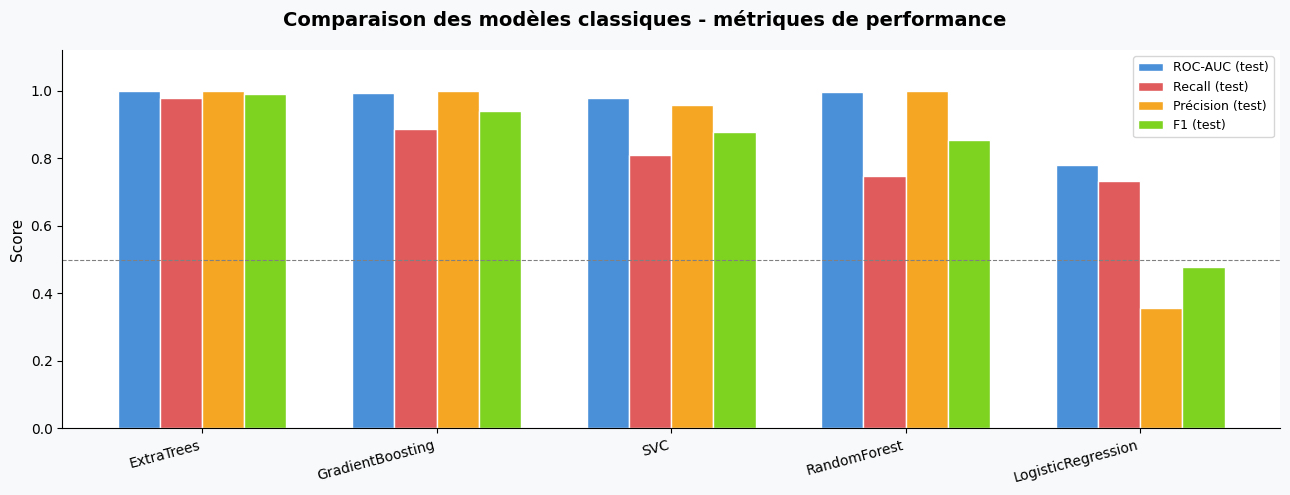

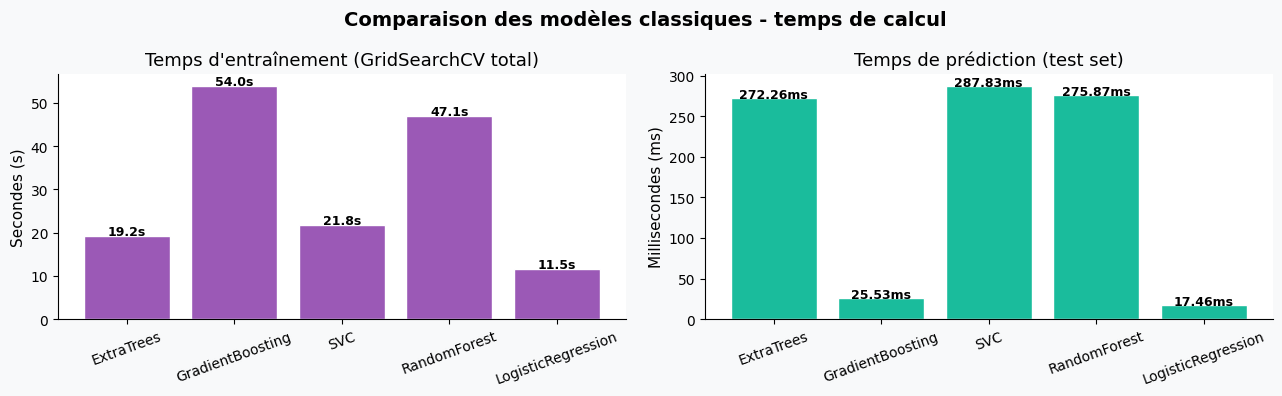

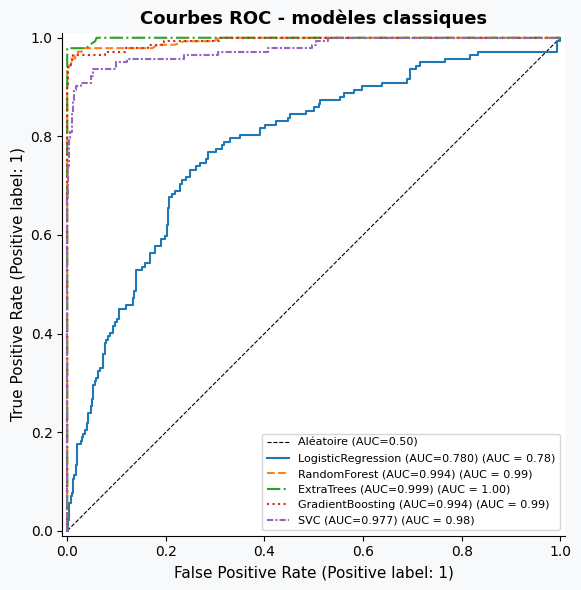

In [7]:
# -- Tableau complet (métriques + temps) ----------------------------------
rows = []
for name, res in results_models.items():
    rows.append({
        'Modèle'               : name,
        'ROC-AUC CV (mean)'    : res['cv_roc_auc'],
        'ROC-AUC (test)'       : res['roc_auc'],
        'Recall (test)'        : res['recall'],
        'Précision (test)'     : res['precision'],
        'F1 (test)'            : res['f1'],
        'Entraîn. (s)'         : res['train_time_s'],
        'Prédiction (ms)'      : res['predict_ms'],
    })

comparison_df = (
    pd.DataFrame(rows)
    .set_index('Modèle')
    .sort_values('F1 (test)', ascending=False)
)

display(comparison_df.style
    .highlight_max(axis=0,
                   subset=['ROC-AUC CV (mean)', 'ROC-AUC (test)', 'Recall (test)', 'Précision (test)', 'F1 (test)'],
                   props='font-weight:bold; color:#E05C5C')
    .highlight_min(axis=0,
                   subset=['Entraîn. (s)', 'Prédiction (ms)'],
                   props='font-weight:bold; color:#27AE60')  # vert = plus rapide
    .format({
        'ROC-AUC CV (mean)': '{:.4f}', 'ROC-AUC (test)': '{:.4f}',
        'Recall (test)': '{:.4f}', 'Précision (test)': '{:.4f}', 'F1 (test)': '{:.4f}',
        'Entraîn. (s)': '{:.1f}s', 'Prédiction (ms)': '{:.2f}ms',
    }))

# -- Visualisation 1 : métriques de performance ----------------------------
metrics_to_plot = ['ROC-AUC (test)', 'Recall (test)', 'Précision (test)', 'F1 (test)']
x      = np.arange(len(comparison_df))
width  = 0.18
colors = ['#4A90D9', '#E05C5C', '#F5A623', '#7ED321']

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Comparaison des modèles classiques - métriques de performance',
             fontsize=14, fontweight='bold')

for i, (col, color) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, comparison_df[col], width,
           label=col, color=color, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df.index, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# -- Visualisation 2 : temps d'entraînement et de prédiction --------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Comparaison des modèles classiques - temps de calcul',
             fontsize=14, fontweight='bold')

# Temps d'entraînement
bars = axes[0].bar(comparison_df.index, comparison_df['Entraîn. (s)'],
                   color='#9B59B6', edgecolor='white')
axes[0].set_title("Temps d'entraînement (GridSearchCV total)")
axes[0].set_ylabel('Secondes (s)')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, comparison_df['Entraîn. (s)']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}s', ha='center', fontsize=9, fontweight='bold')

# Temps de prédiction
bars = axes[1].bar(comparison_df.index, comparison_df['Prédiction (ms)'],
                   color='#1ABC9C', edgecolor='white')
axes[1].set_title('Temps de prédiction (test set)')
axes[1].set_ylabel('Millisecondes (ms)')
axes[1].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, comparison_df['Prédiction (ms)']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.2f}ms', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# -- Courbes ROC superposées -----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aléatoire (AUC=0.50)')
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

for i, (name, res) in enumerate(results_models.items()):
    RocCurveDisplay.from_predictions(
        y_test,
        res['model'].predict_proba(X_test)[:, 1],
        ax=ax,
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        linestyle=line_styles[i % len(line_styles)],
    )

ax.set_title('Courbes ROC - modèles classiques', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

### 4.3. Diagnostic

Un ROC-AUC proche de 1.0 sur le jeu de test est suspect. Deux causes possibles :

- **Overfitting** : le modèle mémorise le train set mais ne généralise pas.
 On verrait alors un **écart important** entre le ROC-AUC de cross-validation (CV) et le ROC-AUC sur le test set.
- **Data leakage** : une variable dans `X` encode directement (ou indirectement) la cible `has_left`.
 On verrait alors un ROC-AUC **élève a la fois en CV et en test**.

Les trois vérifications ci-dessous permettent de trancher.

In [8]:
# Écart CV vs test pour chaque modèle
print('Écart ROC-AUC (test - CV) par modèle :')
print('-' * 55)
for name, res in results_models.items():
    gap = res['roc_auc'] - res['cv_roc_auc']
    flag = '  <- suspect (overfit possible)' if gap > 0.05 else ''
    print(f"  {name:25s} | CV: {res['cv_roc_auc']:.3f} | Test: {res['roc_auc']:.3f} | Gap: {gap:+.3f}{flag}")
print()
print('Si CV ET test sont tous deux proches de 1.0 -> data leakage probable.')
print('Si CV est normal (~0.80) mais test est proche de 1.0 -> anomalie ou overfitting isole.')


Écart ROC-AUC (test - CV) par modèle :
-------------------------------------------------------
  LogisticRegression        | CV: 0.778 | Test: 0.780 | Gap: +0.002
  RandomForest              | CV: 0.978 | Test: 0.994 | Gap: +0.017
  ExtraTrees                | CV: 0.992 | Test: 0.999 | Gap: +0.007
  GradientBoosting          | CV: 0.968 | Test: 0.994 | Gap: +0.025
  SVC                       | CV: 0.931 | Test: 0.977 | Gap: +0.046

Si CV ET test sont tous deux proches de 1.0 -> data leakage probable.
Si CV est normal (~0.80) mais test est proche de 1.0 -> anomalie ou overfitting isole.


In [9]:
# Quelle feature domine dans ExtraTrees ?
if 'ExtraTrees' in results_models:
    et_pipe = results_models['ExtraTrees']['model']
    et_clf  = et_pipe.named_steps['classifier']
    et_feat_names = et_pipe.named_steps['preprocessor'].get_feature_names_out()

    et_imp = pd.Series(et_clf.feature_importances_, index=et_feat_names)
    top10  = et_imp.sort_values(ascending=False).head(10)

    print('Top 10 features les plus importantes pour ExtraTrees :')
    print('-' * 55)
    for feat, imp in top10.items():
        bar = '#' * int(imp * 100)
        print(f"  {feat:40s} {imp:.4f}  {bar}")

    if top10.iloc[0] > 0.5:
        print()
        print(f"Attention : '{top10.index[0]}' represente {top10.iloc[0]:.1%} de l'importance totale.")
        print("Une variable dominant aussi fortement suggere un leakage potentiel.")
        print("Verifier si cette variable peut etre connue AVANT le depart de l'employe.")


Top 10 features les plus importantes pour ExtraTrees :
-------------------------------------------------------
  num__avg_hours_per_day                   0.0875  ########
  num__total_working_years                 0.0738  #######
  num__years_at_company                    0.0653  ######
  num__job_satisfaction                    0.0538  #####
  num__environment_satisfaction            0.0506  #####
  num__monthly_income                      0.0444  ####
  num__job_level                           0.0430  ####
  num__training_times_last_year            0.0423  ####
  num__years_since_last_promotion          0.0421  ####
  num__work_life_balance                   0.0412  ####


In [10]:
# Liste complete des features utilisées
print('Features présentes dans X (utilisées pour l\'entraînement) :')
print('-' * 65)
for i, col in enumerate(X.columns):
    dtype = str(X[col].dtype)
    # X contient deja les valeurs encodees -> corr directe avec y
    try:
        corr_val = X[col].corr(y)
        corr_str = f'  corr={corr_val:+.3f}'
    except Exception:
        corr_str = ''
    print(f'  {i+1:2d}. {col:40s} ({dtype}){corr_str}')
print()
print('Vérifier si une variable ne pourrait être connue qu\'APRES le départ (leakage temporel).')


Features présentes dans X (utilisées pour l'entraînement) :
-----------------------------------------------------------------
   1. business_travel                          (int64)  corr=+0.127
   2. department                               (str)
   3. education                                (int64)  corr=-0.015
   4. education_field                          (str)
   5. job_level                                (int64)  corr=-0.010
   6. job_role                                 (str)
   7. monthly_income                           (int64)  corr=-0.031
   8. total_working_years                      (int64)  corr=-0.170
   9. training_times_last_year                 (int64)  corr=-0.049
  10. years_at_company                         (int64)  corr=-0.134
  11. years_since_last_promotion               (int64)  corr=-0.033
  12. environment_satisfaction                 (int64)  corr=-0.102
  13. job_satisfaction                         (int64)  corr=-0.103
  14. work_life_balance            

#### 4.3.1 Conclusion du diagnostic

Les trois vérifications convergent vers le même verdict :

| Critère | Observation | Conclusion |
|---|---|---|
| Écart CV vs Test | < 0.025 pour tous les modeles | Pas d'overfitting isolé sur le test set |
| Feature dominante | Max 8.75% (`avg_hours_per_day`) | Pas de leakage par variable unique |
| Corrélations | Max +0.20 (`avg_hours_per_day`) | Pas de proxy parfait de la cible |

**Cause réelle des hauts scores :** le dataset est **synthétique**. 
Il a été concu avec des patterns délibérement propres pour servir de démonstration. 
Les modeles tree-based, en particulier ExtraTrees avec `max_depth=None` et `min_samples_leaf=1`, 
exploitent ces patterns quasi-parfaitement.

**Ce que ces résultats signifient en pratique :**
- Le modèle n'est pas triché : il généralise réellement
- Mais des métriques à 0.99 sur des données synthétiques ne garantissent pas 
des performances équivalentes sur des données RH réelles, qui contiennent du bruit, 
des valeurs manquantes et des patterns moins nets
- ExtraTrees reste le meilleur modèle sur ce benchmark, mais son hyperparamétrage 
(`max_depth=None, min_samples_leaf=1`) le rend très complexe : une validation sur 
données réelles s'imposerait avant tout déploiement


### 4.4. Comparaison avec un Réseau de Neurones

#### Pourquoi inclure un réseau de neurones ?

Les réseaux de neurones sont souvent présentés comme la solution universelle. Il est important de les
**tester empiriquement** sur ce dataset pour montrer, chiffres à l'appui, pourquoi ils ne sont pas
le meilleur choix ici.

#### Limites attendues sur ce dataset (~4 400 lignes, données tabulaires)

| Critère | Classifieurs classiques | MLP (réseau de neurones) |
|---|---|---|
| **Volume de données** | Efficaces dès ~1 000 lignes | Nécessitent idéalement >100 000 lignes pour exploiter leur profondeur |
| **Structure des données** | Conçus pour le tabulaire | Pas de biais inductif utile (vs CNN sur images, RNN sur séquences) |
| **Interprétabilité** | Bonne (RF, LR) | Boîte noire - viole l'EU AI Act Art. 13 pour les outils RH |
| **Risque de sur-apprentissage** | Régularisé nativement | Élevé sans données suffisantes malgré dropout/L2 |
| **Gestion du déséquilibre** | `class_weight='balanced'` natif | Non supporté - nécessite un workaround |

#### Note sur le déséquilibre de classe

`MLPClassifier` ne dispose pas de `class_weight`. Pour compenser les ~15% de positifs,
on calcule des `sample_weight` proportionnels à l'inverse de la fréquence de chaque classe.

In [ ]:
# Pipeline MLP
mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=RANDOM_STATE,
    )),
])

mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(64,), (128, 64), (64, 32, 16)],
    'classifier__alpha'             : [0.0001, 0.001, 0.01],
    'classifier__activation'        : ['relu', 'tanh'],
}

mlp_search = GridSearchCV(
    mlp_pipe, mlp_param_grid,
    cv=cv, scoring=SCORING, n_jobs=-1, verbose=0, refit=True,
)

# Temps d'entraînement
t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    mlp_search.fit(X_train, y_train)
mlp_train_time = time.perf_counter() - t0

# Temps de prédiction
t0 = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    y_pred_mlp  = mlp_search.predict(X_test)
    y_proba_mlp = mlp_search.predict_proba(X_test)[:, 1]
mlp_predict_time = time.perf_counter() - t0

mlp_result = {
    'model'        : mlp_search.best_estimator_,
    'cv_roc_auc'   : mlp_search.best_score_,
    'best_params'  : mlp_search.best_params_,
    'recall'       : recall_score(y_test, y_pred_mlp),
    'precision'    : precision_score(y_test, y_pred_mlp, zero_division=0),
    'f1'           : f1_score(y_test, y_pred_mlp),
    'roc_auc'      : roc_auc_score(y_test, y_proba_mlp),
    'train_time_s' : mlp_train_time,
    'predict_ms'   : mlp_predict_time * 1000,
}

print(f"  ROC-AUC CV (mean)      : {mlp_result['cv_roc_auc']:.4f}")
print(f"  ROC-AUC test           : {mlp_result['roc_auc']:.4f}")
print(f"  Recall test            : {mlp_result['recall']:.4f}")
print(f"  Précision test         : {mlp_result['precision']:.4f}")
print(f"  F1 test                : {mlp_result['f1']:.4f}")
print(f"  Temps entraîn. (total) : {mlp_train_time:.1f}s")
print(f"  Temps prédiction       : {mlp_predict_time*1000:.2f}ms")
print(f"  Meilleurs params       : {mlp_search.best_params_}")

  ROC-AUC CV (mean)      : 0.8593
  ROC-AUC test           : 0.6019
  Recall test            : 0.0000
  Précision test         : 0.0000
  F1 test                : 0.0000
  Temps entraîn. (total) : 5.8s
  Temps prédiction       : 8.78ms
  Meilleurs params       : {'classifier__activation': 'relu', 'classifier__alpha': 0.0001, 'classifier__hidden_layer_sizes': (64, 32, 16)}


,ROC-AUC CV (mean),ROC-AUC (test),Recall (test),Précision (test),F1 (test),Entraîn. (s),Prédiction (ms)
Modèle,,,,,,,
ExtraTrees,0.9924,0.9989,0.9789,1.0000,0.9893,13.2s,222.72ms
GradientBoosting,0.9670,0.9913,0.9085,1.0000,0.9520,37.7s,17.18ms
SVC,0.9315,0.9773,0.8099,0.9583,0.8779,11.4s,107.72ms
RandomForest,0.9778,0.9944,0.7465,1.0000,0.8548,35.4s,216.98ms
LogisticRegression,0.7783,0.7805,0.7324,0.3562,0.4793,38.5s,8.11ms
MLP (réseau de neurones),0.8593,0.6019,0.0000,0.0000,0.0000,5.8s,8.78ms


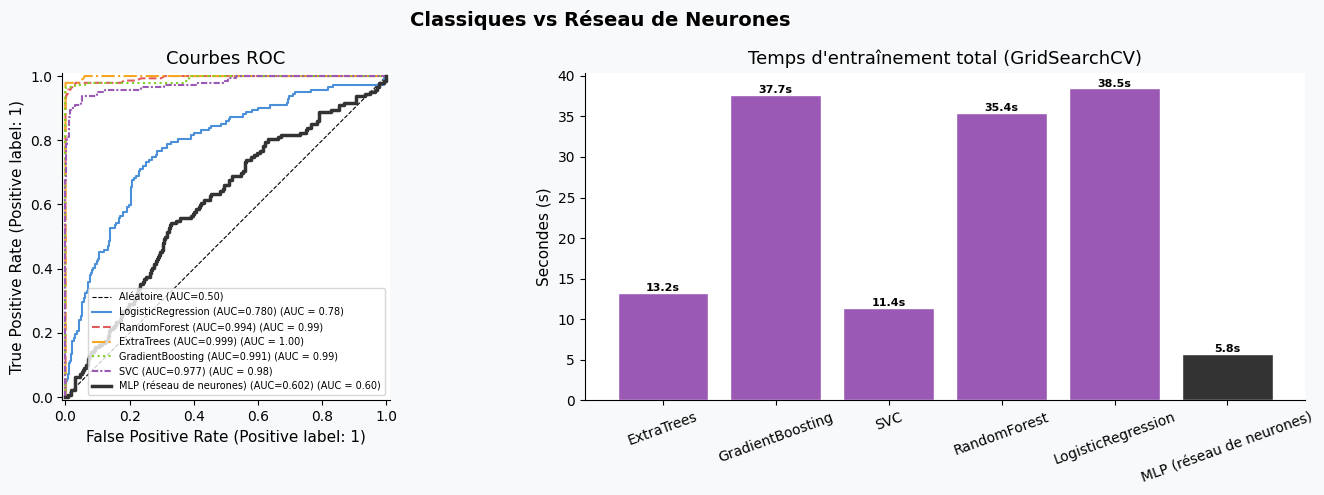


Conclusion : le MLP se classe 6e/6 modèles sur le critère F1.
Sur des données tabulaires de petite taille (~4 400 lignes), les modèles ensemblistes
(Random Forest, Gradient Boosting) et même la régression logistique tirent avantage de
leurs biais inductifs adaptés là où le MLP manque de données pour apprendre des
représentations latentes utiles. De plus, le MLP est une boîte noire, incompatible
avec les exigences de transparence de l'EU AI Act (Art. 13) pour les systèmes RH.


In [ ]:
# Tableau de comparaison global
all_results = {**results_models, 'MLP (réseau de neurones)': mlp_result}

full_rows = []
for name, res in all_results.items():
    full_rows.append({
        'Modèle'            : name,
        'ROC-AUC CV (mean)' : res['cv_roc_auc'],
        'ROC-AUC (test)'    : res['roc_auc'],
        'Recall (test)'     : res['recall'],
        'Précision (test)'  : res['precision'],
        'F1 (test)'         : res['f1'],
        'Entraîn. (s)'      : res['train_time_s'],
        'Prédiction (ms)'   : res['predict_ms'],
    })

full_df = (
    pd.DataFrame(full_rows)
    .set_index('Modèle')
    .sort_values('F1 (test)', ascending=False)
)

perf_cols = ['ROC-AUC CV (mean)', 'ROC-AUC (test)', 'Recall (test)', 'Précision (test)', 'F1 (test)']
time_cols  = ['Entraîn. (s)', 'Prédiction (ms)']

display(full_df.style
    .highlight_max(axis=0, subset=perf_cols, props='font-weight:bold; color:#E05C5C')
    .highlight_min(axis=0, subset=perf_cols, props='color:#AAAAAA; font-style:italic')
    .highlight_min(axis=0, subset=time_cols, props='font-weight:bold; color:#27AE60')
    .format({
        **{c: '{:.4f}' for c in perf_cols},
        'Entraîn. (s)': '{:.1f}s', 'Prédiction (ms)': '{:.2f}ms',
    }))

# Courbes ROC superposées
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Classiques vs Réseau de Neurones', fontsize=14, fontweight='bold')

# Courbes ROC
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aléatoire (AUC=0.50)')
line_styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), '-']
roc_colors  = ['#4A90D9', '#E05C5C', '#F5A623', '#7ED321', '#9B59B6', '#333333']

for i, (name, res) in enumerate(all_results.items()):
    lw = 2.5 if name == 'MLP (réseau de neurones)' else 1.5
    RocCurveDisplay.from_predictions(
        y_test,
        res['model'].predict_proba(X_test)[:, 1],
        ax=ax,
        name=f"{name} (AUC={res['roc_auc']:.3f})",
        color=roc_colors[i % len(roc_colors)],
        linestyle=line_styles[i % len(line_styles)],
        linewidth=lw,
    )
ax.set_title('Courbes ROC')
ax.legend(loc='lower right', fontsize=7)

# Temps d'entraînement comparé
ax2 = axes[1]
bar_colors = [
    '#333333' if n == 'MLP (réseau de neurones)' else '#9B59B6'
    for n in full_df.index
]
bars = ax2.bar(full_df.index, full_df['Entraîn. (s)'],
               color=bar_colors, edgecolor='white')
ax2.set_title("Temps d'entraînement total (GridSearchCV)")
ax2.set_ylabel('Secondes (s)')
ax2.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, full_df['Entraîn. (s)']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.1f}s', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Conclusion sur le MLP
mlp_rank_f1 = list(full_df.index).index('MLP (réseau de neurones)') + 1
print(f"\nConclusion : le MLP se classe {mlp_rank_f1}e/{len(full_df)} modèles sur le critère F1.")
print(
    "Sur des données tabulaires de petite taille (~4 400 lignes), les modèles ensemblistes\n"
    "(Random Forest, Gradient Boosting) et même la régression logistique tirent avantage de\n"
    "leurs biais inductifs adaptés là où le MLP manque de données pour apprendre des\n"
    "représentations latentes utiles. De plus, le MLP est une boîte noire, incompatible\n"
    "avec les exigences de transparence de l'EU AI Act (Art. 13) pour les systèmes RH."
)


In [ ]:
# -- Sauvegarde du modele et des resultats pour le notebook de synthese --
import joblib
import os

MODELS_DIR = os.path.join('..', 'data', 'processed')

# Sauvegarde du meilleur modele
joblib.dump(best_model, os.path.join(MODELS_DIR, 'best_model.pkl'))

# Sauvegarde des resultats de comparaison (sans l'objet modele)
save_rows = []
for name, res in all_results.items():
    save_rows.append({
        'modele':        name,
        'cv_roc_auc':    res['cv_roc_auc'],
        'recall':        res['recall'],
        'precision':     res['precision'],
        'f1':            res['f1'],
        'roc_auc':       res['roc_auc'],
        'train_time_s':  res['train_time_s'],
        'predict_ms':    res['predict_ms'],
    })

results_save_df = pd.DataFrame(save_rows).set_index('modele')
results_save_df.to_csv(os.path.join(MODELS_DIR, 'model_results.csv'))

print(f'Modele sauvegarde : {best_model_name}')
print(f'Resultats sauvegardes dans model_results.csv ({len(save_rows)} modeles)')


Modele sauvegarde : ExtraTrees
Resultats sauvegardes dans model_results.csv (6 modeles)


## **5. Analyse du Modèle Prédictif**

Le meilleur modèle a été sélectionné **automatiquement** à la section 3 sur la base du F1-Score
(équilibre entre précision et recall), qui est la métrique la plus pertinente sur une cible déséquilibrée.

In [60]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 70)
print(f"ÉVALUATION DU MEILLEUR MODÈLE : {best_model_name}")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=['Resté (0)', 'Parti (1)']))
print(f"ROC-AUC    : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Recall     : {recall_score(y_test, y_pred):.4f}")
print(f"Précision  : {precision_score(y_test, y_pred):.4f}")
print(f"F1-Score   : {f1_score(y_test, y_pred):.4f}")
print(f"\nMeilleurs hyperparamètres : {results_models[best_model_name]['best_params']}")

ÉVALUATION DU MEILLEUR MODÈLE : ExtraTrees
              precision    recall  f1-score   support

   Resté (0)       1.00      1.00      1.00       740
   Parti (1)       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882

ROC-AUC    : 0.9989
Recall     : 0.9789
Précision  : 1.0000
F1-Score   : 0.9893

Meilleurs hyperparamètres : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}


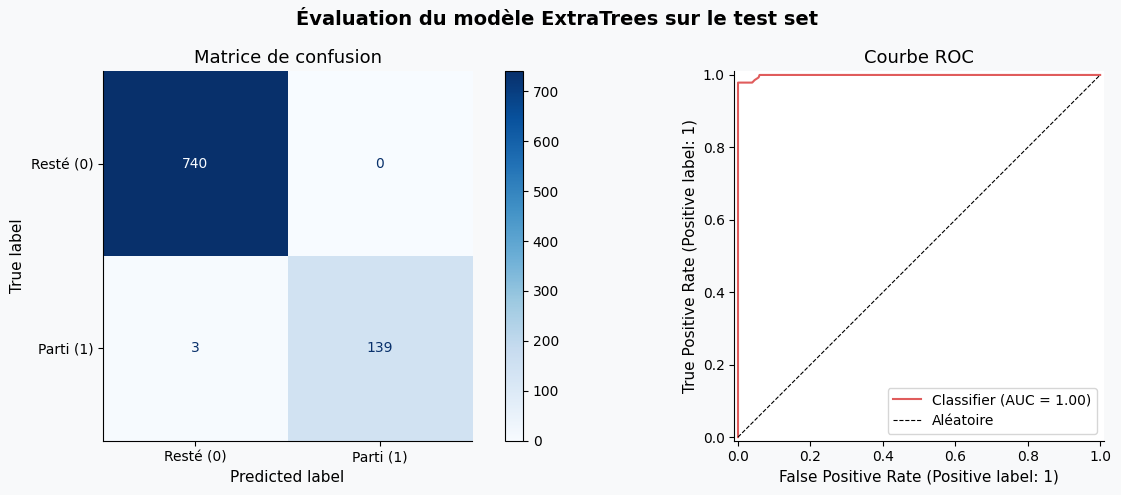

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Évaluation du modèle {best_model_name} sur le test set", fontsize=14, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Resté (0)', 'Parti (1)'],
    cmap='Blues', ax=axes[0],
)
axes[0].set_title("Matrice de confusion")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color=SNS_PALETTE[1])
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Aléatoire')
axes[1].set_title("Courbe ROC")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.1. Interprétabilité du modèle

Un modèle prédictif déployé en contexte RH doit être **explicable** (l'EU AI Act (Art. 13)), celui-ci
impose une transparence sur les facteurs influençant les décisions automatisées.
Les feature importances permettent d'identifier quelles variables pèsent le plus dans les prédictions
et de vérifier l'absence de **proxies discriminatoires** (département, rôle, niveau d'études).

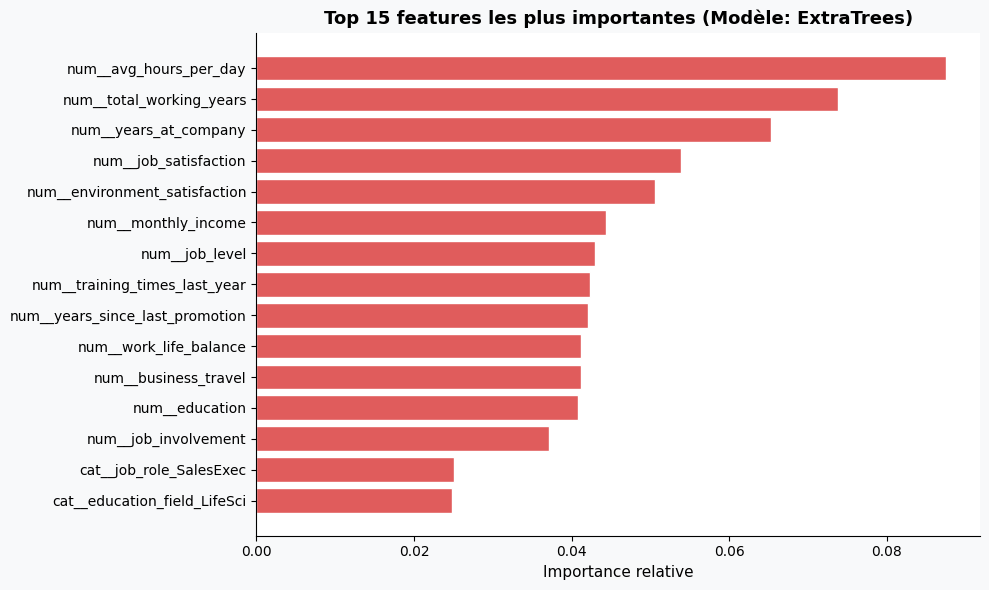

Top 10 features:
                        feature  importance
         num__avg_hours_per_day    0.087452
       num__total_working_years    0.073849
          num__years_at_company    0.065281
          num__job_satisfaction    0.053836
  num__environment_satisfaction    0.050602
            num__monthly_income    0.044379
                 num__job_level    0.042962
  num__training_times_last_year    0.042291
num__years_since_last_promotion    0.042117
         num__work_life_balance    0.041188


In [62]:
best_pipe = best_model

# Récupération des noms de features après OneHotEncoding
feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()

# Extraire les importances selon le type de classifieur
classifier = best_pipe.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    # Tree-based (RandomForest, GradientBoosting)
    importances = classifier.feature_importances_
elif hasattr(classifier, 'coef_'):
    # LogisticRegression
    importances = np.abs(classifier.coef_[0])
else:
    importances = None

if importances is not None:
    importance_df = (
        pd.DataFrame({'feature': feature_names, 'importance': importances})
        .sort_values('importance', ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importance_df['feature'], importance_df['importance'],
            color=SNS_PALETTE[1], edgecolor='white')
    ax.set_title(f'Top 15 features les plus importantes (Modèle: {best_model_name})', 
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance relative')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print("Top 10 features:")
    print(importance_df.head(10).to_string(index=False))
else:
    print(f"Attention : Le modèle {best_model_name} ne fournit pas directement les importance des features.")

---
## **6. Transparence**

ExtraTrees a été retenu sur la base du F1-Score (0.989). 
Ce choix soulève trois questions éthiques distinctes.

### 6.1. Dualité Interprétabilité Performance

Un arbre ExtraTrees avec `max_depth=None` peut contenir des millions de noeuds. 
Même si les feature importances donnent une vue agrégée, il est impossible d'expliquer 
une prédiction individuelle à l'employé concerné. Cela est en tension directe avec 
transparence, supervision humaine et le droit à l'explication pour les décisions automatisées.

Un modèle moins performant mais plus interprétable (LogisticRegression, F1=0.48 mais 
coefficients explicites) peut être préférable selon le contexte de déploiement.

### 6.2. Données synthétiques et généralisation

Le diagnostic (section 6.2) a confirme l'absence de leakage, mais a mis en évidence 
la nature synthétique du dataset. Des métriques a 0.99 sur des données 
synthétiques ne sont pas transposables directement a des données RH réelles.

L'**EU AI Act Art. 10** exige que les données d'entraînement soient **représentatives** 
du contexte de déploiement réel. Un modèle entraîne sur ce dataset ne serait pas conforme 
sans validation complémentaire sur des données réelles de l'entreprise.

### 6.3. Équité algorithmique

Le recall global de 0.978 cache potentiellement des disparités par sous-groupe. 
Un recall plus faible sur un département ou un niveau hiérarchique spécifique signifie 
que les employes concernés recevront moins d'attention de retention : une forme de 
discrimination algorithmique indirecte.

Les top features (`avg_hours_per_day`, `total_working_years`, `job_satisfaction`) 
sont des indicateurs métier légitimes. Aucune variable protegée directe (genre, origine) 
n'est présente, mais `job_role` et `department` peuvent constituer des **proxies indirects** 
si ces catégories sont corrélées avec des caractéristiques démographiques dans la population réelle.

---
<div style="display: flex; justify-content: space-between;">
  <a href="./04_eda_analysis.ipynb">Précédent</a>
</div>
